#  Cuaderno de Prácticas: Sesión 1 - La Ciencia de la Medición

**Objetivo:** Establecer el Baseline de rendimiento en CPU y comprender la diferencia entre Latencia y Throughput.

---

### 1.1 El Ferrari vs. El Autobús

En HPC (High Performance Computing), no buscamos que "una tarea acabe rápido" (**Latencia**), sino "acabar muchas tareas por segundo" (**Throughput**).

* **CPU (El Ferrari):** Diseñada para baja latencia. Pocos núcleos, muy complejos, mucha caché. Excelente para lógica secuencial y S.O.
* **GPU (El Autobús):** Diseñada para alto throughput. Miles de núcleos simples. Pésima latencia, pero inigualable moviendo grandes volúmenes de datos.

> **Analogía:** Si tienes que llevar a una persona al aeropuerto, el Ferrari gana. Si tienes que llevar a 100 personas, el Autobús gana por goleada.

Hoy vamos a medir cuánto corre nuestro Ferrari (CPU) para tener un dato real (**Ground Truth**) que intentar batir después.


###  2.1 Inspección del Hardware
Antes de medir, miremos qué CPU nos ha asignado Google Colab. Fíjate en la frecuencia y en la **Caché L3** (es vital para entender el rendimiento).

In [36]:
# Ver información de la CPU asignada
!lscpu | grep -E "Model name|Socket|Core|Thread|L1d|L1i|L2|L3"

Model name:                              Intel(R) Xeon(R) CPU @ 2.00GHz
Thread(s) per core:                      2
Core(s) per socket:                      1
Socket(s):                               1
L1d cache:                               32 KiB (1 instance)
L1i cache:                               32 KiB (1 instance)
L2 cache:                                1 MiB (1 instance)
L3 cache:                                38.5 MiB (1 instance)


### 3.1 Cómo mentir con estadísticas
En HPC, medir mal es peor que no medir. Un error común es incluir "ruido" dentro del cronómetro.

El siguiente código comete **3 Errores Capitales**:
1.  **Mide la gestión de memoria:** `std::vector` y `malloc` son lentos y variables. No son cómputo.
2.  **Mide la generación de datos:** `rand()` es lentísimo.
3.  **Mide la salida (I/O):** `cout` o `printf` destruyen el rendimiento.

Ejecútalo y observa el tiempo. ¿Es fiable?

In [37]:
%%writefile bad_benchmark.cpp
#include <iostream>
#include <vector>
#include <ctime>   // Reloj de baja resolución (Mala idea)
#include <cstdlib>

void process_data(std::vector<int>& data) {
    // Simula trabajo
    for(size_t i = 0; i < data.size(); i++) data[i] *= 2;
}

int main() {
    // ERROR: Usar clock() en lugar de chrono
    clock_t start = clock();

    // ERROR: Medir la reserva de memoria
    std::vector<int> data(10000000);

    // ERROR: Medir la generación de datos (rand)
    for(auto &x : data) x = rand();

    process_data(data);

    // ERROR: Medir el printf
    std::cout << "Terminado." << std::endl;

    clock_t end = clock();

    // El resultado incluirá el tiempo de reservar RAM y escribir en pantalla
    std::cout << "Tiempo (Sucio): " << (double)(end-start)/CLOCKS_PER_SEC << " s" << std::endl;
    return 0;
}

Writing bad_benchmark.cpp


In [38]:
# Compilamos sin optimización (-O0) y ejecutamos
!g++ -O0 bad_benchmark.cpp -o bad_bench
!./bad_bench

Terminado.
Tiempo (Sucio): 0.330755 s


**Respuesta:**


Esos 0.347174 segundos son engañosos porque estoamos midiendo un montón de "basura" junto con nuestra código.
De ese tiempo, casi todo se gastó en pedirle la memoria RAM al sistema para los 10 millones de datos, Usar rand() para rellenar todo el vector (esto es lo que más tarda, es lentísimo) y hacer el cout para imprimir "Terminado." en la pantalla.
Como el cronómetro incluyó todo lo demás, nuestro resultado es "sucio" y no nos sirve para saber qué tan rápido es realmente nuestro algoritmo.

### 4.1 Protocolo de Medición Rigurosa
Para obtener un dato científico, aplicaremos el protocolo estándar:

1.  **Aislamiento:** Medimos SOLO el kernel (`saxpy_cpu`). La memoria se prepara antes.
2.  **Warm-up (Calentamiento):** Ejecutamos una vez "en sucio" para cargar la caché y la TLB.
3.  **Promedio:** Ejecutamos N veces y hacemos la media.
4.  **Baseline Honesto:** Compilamos con `-O3` (optimización máxima) para comparar contra la mejor versión posible de la CPU.

In [ ]:
%%writefile good_benchmark.cpp
#include <iostream>
#include <vector>
#include <chrono>
#include <numeric>
#include <cmath>    // Para sqrt y pow
#include <iomanip>  // Para setprecision

// Kernel: SAXPY
void saxpy_cpu(int n, float a, const float *x, float *y) {
    for (int i = 0; i < n; ++i) {
        y[i] = a * x[i] + y[i];
    }
}

int main() {
    const int N = 1 << 24; // 16 Millones (~64 MB)
    const int ITERATIONS = 20;
    const float a = 2.5f;

    std::cout << "--- INICIO EXPERIMENTO CIENTÍFICO ---" << std::endl;
    std::cout << "Elementos: " << N << " | Memoria: " << (N*4.0)/(1024*1024) << " MB" << std::endl;

    // 1. PREPARACIÓN
    std::vector<float> x(N, 1.0f);
    std::vector<float> y(N, 2.0f);

    // 2. WARM-UP (Vital para evitar el primer dato frío)
    saxpy_cpu(N, a, x.data(), y.data());

    // Vector para guardar CADA tiempo individual
    std::vector<double> times;
    times.reserve(ITERATIONS);

    // 3. MEDICIÓN
    for(int i=0; i<ITERATIONS; i++) {
        auto start = std::chrono::high_resolution_clock::now();

        saxpy_cpu(N, a, x.data(), y.data());

        auto end = std::chrono::high_resolution_clock::now();
        std::chrono::duration<double> elapsed = end - start;
        times.push_back(elapsed.count());
    }

    // 4. ESTADÍSTICA
    // A) Media
    double sum = std::accumulate(times.begin(), times.end(), 0.0);
    double mean = sum / times.size();

    // B) Desviación Estándar (Std Dev)
    double sq_sum = 0.0;
    for(double t : times) {
        sq_sum += (t - mean) * (t - mean);
    }
    double stdev = std::sqrt(sq_sum / times.size());

    // C) Coeficiente de Variación (CV) - ¿Cuán estable es?
    double cv = (stdev / mean) * 100.0;

    // Cálculo de ancho de banda con la media
    double bytes = 3.0 * N * sizeof(float);
    double gb_s = (bytes / mean) / 1e9;

    std::cout << std::fixed << std::setprecision(4);
    std::cout << "--------------------------------------" << std::endl;
    std::cout << "Tiempo Medio      : " << mean * 1000.0 << " ms" << std::endl;
    std::cout << "Desviación Std    : " << stdev * 1000.0 << " ms" << std::endl;
    std::cout << "Variabilidad (CV) : " << cv << " %" << std::endl;
    std::cout << "--------------------------------------" << std::endl;
    std::cout << "Ancho de Banda    : " << gb_s << " GB/s" << std::endl;

    if(cv > 5.0) {
        std::cout << " ALERTA: Sistema inestable (CV > 5%). Hay ruido del S.O." << std::endl;
    } else {
        std::cout <<  ESTADO: Medición robusta y científica." << std::endl;
    }

    return 0;
}

Overwriting good_benchmark.cpp


In [40]:
# Compilamos con optimización máxima (-O3)
!g++ -O3 good_benchmark.cpp -o good_bench
!./good_bench

--- INICIO EXPERIMENTO CIENTÍFICO ---
Elementos: 16777216 | Memoria: 64 MB
--------------------------------------
Tiempo Medio      : 11.5544 ms
Desviación Std    : 0.3225 ms
Variabilidad (CV) : 2.7913 %
--------------------------------------
Ancho de Banda    : 17.4242 GB/s
✅ ESTADO: Medición robusta y científica.


**Modificacion del código good_benchmark.cpp (cambiando el valor de N)**


In [41]:
%%writefile good_benchmark.cpp
#include <iostream>
#include <vector>
#include <chrono>
#include <numeric>
#include <cmath>    // Para sqrt y pow
#include <iomanip>  // Para setprecision

// Kernel: SAXPY
void saxpy_cpu(int n, float a, const float *x, float *y) {
    for (int i = 0; i < n; ++i) {
        y[i] = a * x[i] + y[i];
    }
}

int main() {
    const int N = 1 << 20; // 16 Millones (~64 MB)
    const int ITERATIONS = 20;
    const float a = 2.5f;

    std::cout << "--- INICIO EXPERIMENTO CIENTÍFICO ---" << std::endl;
    std::cout << "Elementos: " << N << " | Memoria: " << (N*4.0)/(1024*1024) << " MB" << std::endl;

    // 1. PREPARACIÓN
    std::vector<float> x(N, 1.0f);
    std::vector<float> y(N, 2.0f);

    // 2. WARM-UP (Vital para evitar el primer dato frío)
    saxpy_cpu(N, a, x.data(), y.data());

    // Vector para guardar CADA tiempo individual
    std::vector<double> times;
    times.reserve(ITERATIONS);

    // 3. MEDICIÓN
    for(int i=0; i<ITERATIONS; i++) {
        auto start = std::chrono::high_resolution_clock::now();

        saxpy_cpu(N, a, x.data(), y.data());

        auto end = std::chrono::high_resolution_clock::now();
        std::chrono::duration<double> elapsed = end - start;
        times.push_back(elapsed.count());
    }

    // 4. ESTADÍSTICA
    // A) Media
    double sum = std::accumulate(times.begin(), times.end(), 0.0);
    double mean = sum / times.size();

    // B) Desviación Estándar (Std Dev)
    double sq_sum = 0.0;
    for(double t : times) {
        sq_sum += (t - mean) * (t - mean);
    }
    double stdev = std::sqrt(sq_sum / times.size());

    // C) Coeficiente de Variación (CV) - ¿Cuán estable es?
    double cv = (stdev / mean) * 100.0;

    // Cálculo de ancho de banda con la media
    double bytes = 3.0 * N * sizeof(float);
    double gb_s = (bytes / mean) / 1e9;

    std::cout << std::fixed << std::setprecision(4);
    std::cout << "--------------------------------------" << std::endl;
    std::cout << "Tiempo Medio      : " << mean * 1000.0 << " ms" << std::endl;
    std::cout << "Desviación Std    : " << stdev * 1000.0 << " ms" << std::endl;
    std::cout << "Variabilidad (CV) : " << cv << " %" << std::endl;
    std::cout << "--------------------------------------" << std::endl;
    std::cout << "Ancho de Banda    : " << gb_s << " GB/s" << std::endl;

    if(cv > 5.0) {
        std::cout << "⚠️ ALERTA: Sistema inestable (CV > 5%). Hay ruido del S.O." << std::endl;
    } else {
        std::cout << "✅ ESTADO: Medición robusta y científica." << std::endl;
    }

    return 0;
}

Overwriting good_benchmark.cpp


In [42]:
!g++ -O3 good_benchmark.cpp -o good_bench
!./good_bench

--- INICIO EXPERIMENTO CIENTÍFICO ---
Elementos: 16777216 | Memoria: 64 MB
--------------------------------------
Tiempo Medio      : 11.3935 ms
Desviación Std    : 0.3054 ms
Variabilidad (CV) : 2.6809 %
--------------------------------------
Ancho de Banda    : 17.6703 GB/s
✅ ESTADO: Medición robusta y científica.


###  5.1 El Muro de la Memoria
La CPU tiene un límite físico.

**Tu Misión:**
Modifica el código `good_benchmark.cpp` (puedes editar la celda anterior) cambiando el valor de `N`:
1.  **N pequeño ($2^{10}$):** El tiempo es tan bajo que el ruido domina.
2.  **N gigante ($2^{28}$):** La CPU se satura esperando datos de la RAM.

> **Reflexión:** El dato de GB/s que acabas de obtener (~20-30 GB/s) es tu **línea base**. La GPU promete teóricamente ~300 GB/s. ¿Podremos alcanzarlo?

**respuesta**

Sí, es posible alcanzar los ~300 GB/s transitando de un modelo secuencial a un paradigma de ejecución paralela.
Nuestra línea base de ~20-30 GB/s en CPU evidencia el Memory Wall, un cuello de botella físico dictado por el ancho del bus de la memoria DDR.
La GPU mitiga este límite utilizando arquitecturas de memoria especializadas con buses masivamente anchos para priorizar el throughput.
Para saturar dicho ancho de banda, debemos programar un kernel que garantice patrones de acceso a memoria estrictamente coaligados (coalesced memory access)

In [43]:
%%writefile scalable_benchmark_adaptive.cpp
#include <iostream>   // std::cout
#include <vector>     // std::vector (memoria contigua)
#include <chrono>     // Medición precisa de tiempo
#include <cstdlib>    // std::atoll
#include <algorithm>  // (No imprescindible aquí, pero habitual en benchmarks)

// ------------------------------------------------------------
// SAXPY en CPU: y[i] = a * x[i] + y[i]
// Operación típica de BLAS, muy usada para medir ancho de banda
// ------------------------------------------------------------
void saxpy_cpu(long long n, float a, const float *x, float *y) {
    //COMPLETAR
}

int main(int argc, char* argv[]) {

    // Se espera el tamaño del vector como argumento
    if (argc < 2) {
        std::cerr << "Uso: " << argv[0] << " <N>\n";
        return 1;
    }

    // Tamaño del problema (puede ser muy grande → 64 bits)
    long long N = std::atoll(argv[1]);

    const float a = 2.5f;

    // Inicialización de los vectores en memoria contigua
    // x = 1.0, y = 2.0 para evitar efectos de datos aleatorios
    std::vector<float> x(N, 1.0f);
    std::vector<float> y(N, 2.0f);

    // ------------------------------------------------------------
    // Warm-up: evita medir efectos de:
    //  - page faults
    //  - inicialización diferida
    //  - calentamiento de cachés
    // ------------------------------------------------------------
    saxpy_cpu(N, a, x.data(), y.data());

    // ------------------------------------------------------------
    // LÓGICA ADAPTATIVA
    // Queremos mover ~2GB de datos independientemente de N.
    // Así todos los tamaños hacen un trabajo comparable.
    // ------------------------------------------------------------

    // 2 GB en bytes (LL fuerza cálculo en 64 bits → evita overflow)
    long long target_bytes = 2LL * 1024 * 1024 * 1024;

    // Cada iteración SAXPY mueve:
    //  Leer x[i]  -> 4 bytes
    //  Leer y[i]  -> 4 bytes
    //  Escribir y[i] -> 4 bytes
    //  Total = 12 bytes = 3 * sizeof(float)
    long long bytes_per_iter = 3LL * N * sizeof(float);

    // Número de repeticiones necesarias para alcanzar ~2GB movidos
    long long iterations = target_bytes / bytes_per_iter;

    // Aseguramos mínimo de iteraciones para estabilidad temporal
    if (iterations < 5) iterations = 5;

    // ------------------------------------------------------------
    // MEDICIÓN DE TIEMPO
    // ------------------------------------------------------------
    auto start = std::chrono::high_resolution_clock::now();

    for (long long i = 0; i < iterations; ++i) {
        saxpy_cpu(N, a, x.data(), y.data());
    }

    auto end = std::chrono::high_resolution_clock::now();

    std::chrono::duration<double> elapsed = end - start;

    // Tiempo medio por iteración
    double avg_time = elapsed.count() / iterations;

    // ------------------------------------------------------------
    // CÁLCULO DE RENDIMIENTO (GB/s efectivos)
    // ------------------------------------------------------------
    double gb_s = (bytes_per_iter / avg_time) / 1e9;

    // Salida CSV: tamaño del problema, ancho de banda alcanzado
    std::cout << N << "," << gb_s << std::endl;

    return 0;
}


Overwriting scalable_benchmark_adaptive.cpp


In [44]:
# Compilamos el benchmark escalable con máxima optimización
!g++ -O3 scalable_benchmark_adaptive.cpp -o scalable_adaptive

🚀 Ejecutando Benchmark Adaptativo... (Esto puede tardar unos segundos)


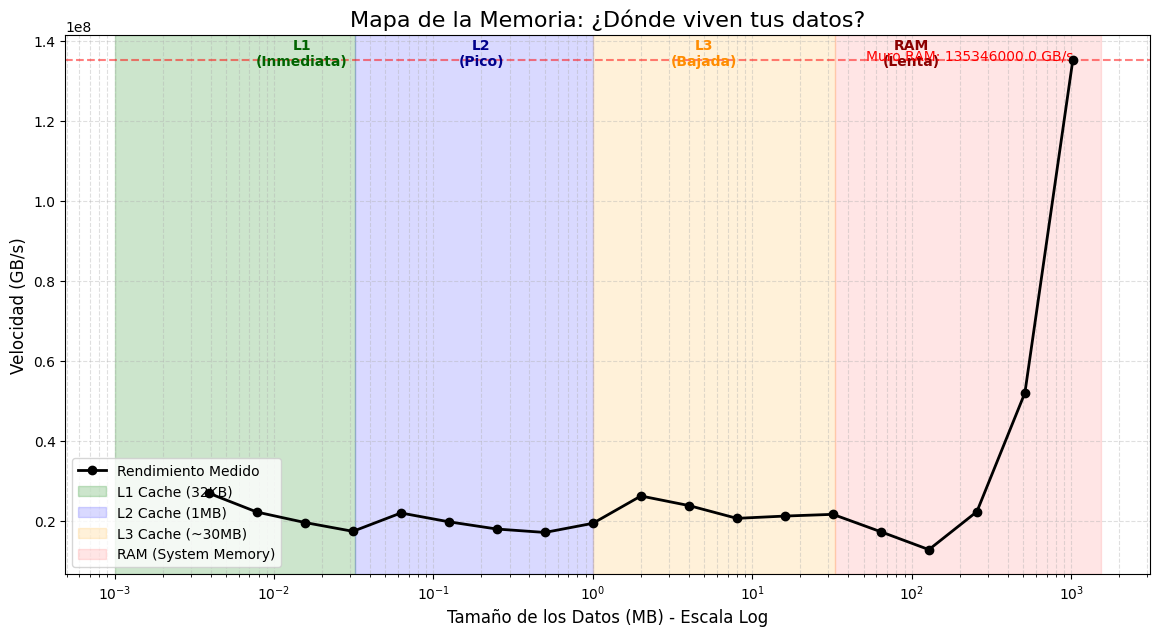

In [45]:
import subprocess
import matplotlib.pyplot as plt
import numpy as np

# --- 1. EJECUCIÓN DEL EXPERIMENTO ---
# Definimos el rango: 2^10 (1KB) hasta 2^28 (256MB)
powers = range(10, 29)
sizes = [1 << p for p in powers]
bandwidths = []
memory_sizes_mb = []

print("🚀 Ejecutando Benchmark Adaptativo... (Esto puede tardar unos segundos)")

for n in sizes:
    # Llamamos al ejecutable C++ que compilamos antes
    # Asegúrate de haber ejecutado la celda de compilación: !g++ -O3 ... -o scalable_adaptive
    result = subprocess.run(["./scalable_adaptive", str(n)], capture_output=True, text=True)
    try:
        output = result.stdout.strip().split(',')
        gb_s = float(output[1])
        bandwidths.append(gb_s)
        memory_sizes_mb.append((n * 4) / (1024**2)) # Convertir a MB
    except:
        pass # Si falla alguna ejecución puntual, seguimos

# --- 2. VISUALIZACIÓN EDUCATIVA (CON COLORES) ---
plt.figure(figsize=(14, 7))

# Dibujamos la línea de datos
plt.plot(memory_sizes_mb, bandwidths, marker='o', color='black', linewidth=2, label='Rendimiento Medido', zorder=10)

# COLOREAMOS LOS TERRITORIOS (Estimación típica para Intel Xeon en Colab)
max_y = max(bandwidths) * 1.1 # Altura para los textos

# L1 Cache (< 32 KB) - Zona Verde
plt.axvspan(0.001, 0.032, color='green', alpha=0.2, label='L1 Cache (32KB)')
plt.text(0.015, max_y*0.9, 'L1\n(Inmediata)', color='darkgreen', ha='center', fontweight='bold')

# L2 Cache (32 KB - 1 MB) - Zona Azul
plt.axvspan(0.032, 1.0, color='blue', alpha=0.15, label='L2 Cache (1MB)')
plt.text(0.2, max_y*0.9, 'L2\n(Pico)', color='darkblue', ha='center', fontweight='bold')

# L3 Cache (1 MB - 30 MB) - Zona Naranja
plt.axvspan(1.0, 33.0, color='orange', alpha=0.15, label='L3 Cache (~30MB)')
plt.text(5, max_y*0.9, 'L3\n(Bajada)', color='darkorange', ha='center', fontweight='bold')

# RAM (> 30 MB) - Zona Roja
plt.axvspan(33.0, max(memory_sizes_mb)*1.5, color='red', alpha=0.1, label='RAM (System Memory)')
plt.text(100, max_y*0.9, 'RAM\n(Lenta)', color='darkred', ha='center', fontweight='bold')

# Ajustes finales del gráfico
plt.xscale('log') # Escala Logarítmica necesaria para ver todas las zonas
plt.grid(True, which="both", ls="--", alpha=0.4)

plt.title('Mapa de la Memoria: ¿Dónde viven tus datos?', fontsize=16)
plt.xlabel('Tamaño de los Datos (MB) - Escala Log', fontsize=12)
plt.ylabel('Velocidad (GB/s)', fontsize=12)
plt.legend(loc='lower left')

# Marcamos el límite de la RAM
ram_speed = bandwidths[-1]
plt.axhline(y=ram_speed, color='red', linestyle='--', alpha=0.5)
plt.text(max(memory_sizes_mb), ram_speed+2, f'Muro RAM: {ram_speed:.1f} GB/s', color='red', ha='right')

plt.show()

"La Autopsia del Compilador"
**texto en negrita**

* **Objetivo**: Implementar una multiplicación de matrices (C=A×B) en C++ y medir el impacto real de las optimizaciones del compilador y la jerarquía de caché.

Tareas:

    Escribir un código base de multiplicación de matrices triple bucle (O(n3)).

    Implementar una metodología de medición profesional (Warm-up + múltiples iteraciones).

    Comparar el rendimiento (GFLOPS) usando cuatro niveles de optimización:

        -O0: Sin optimización (código plano).

        -O2: Optimización estándar.

        -O3: Optimización agresiva (vectorización automática).

        -O3 -ffast-math: Rompiendo reglas de precisión IEEE para ganar velocidad.

In [65]:
%%writefile matmul.cpp
#include <iostream>
#include <vector>
#include <chrono>
#include <iomanip>
#include <cmath>

using namespace std;

// Función para multiplicar matrices (Triple bucle básico)
void multiply(const vector<double>& A, const vector<double>& B, vector<double>& C, int N) {
   // Función para multiplicar matrices (Triple bucle básico)
   for (int i = 0; i < N; ++i) {
    for (int j = 0; j < N; ++j) {
        for (int k = 0; k < N; ++k) {
            C[i * N + j] += A[i * N + k] * B[k * N + j];
        }
    }
}
}


int main(int argc, char** argv) {
    int N = (argc > 1) ? atoi(argv[1]) : 512;
    int iterations = 5;

    vector<double> A(N * N, 1.1), B(N * N, 2.2), C(N * N, 0.0);

    // 1. WARM-UP (Ejecución de descarte)
    multiply(A, B, C, N);

    // 2. MEDICIÓN CIENTÍFICA
    double total_time = 0;
    for (int i = 0; i < iterations; i++) {
        auto start = chrono::high_resolution_clock::now();
        multiply(A, B, C, N);
        auto end = chrono::high_resolution_clock::now();

        chrono::duration<double> diff = end - start;
        total_time += diff.count();
    }

    double avg_time = total_time / iterations;
    // Cálculo de GFLOPS: (2 * N^3 operaciones) / (tiempo * 1e9)
    double gflops = (2.0 * pow(N, 3)) / (avg_time * 1e9);

    cout << fixed << setprecision(4);
    cout << "N=" << N << " | Tiempo Medio: " << avg_time << "s | Rendimiento: " << gflops << " GFLOPS" << endl;

    return 0;
}

Overwriting matmul.cpp


In [63]:
%%writefile matmul.cpp
#include <iostream>
#include <vector>
#include <chrono>
#include <iomanip>
#include <cmath>

using namespace std;

// Función para multiplicar matrices (Triple bucle básico)
void multiply(const vector<double>& A, const vector<double>& B, vector<double>& C, int N) {
   // Función para multiplicar matrices (ikj)
   for (int i = 0; i < N; ++i) {
    for (int k = 0; k < N; ++k) {
        double rA = A[i * N + k];
        for (int j = 0; j < N; ++j) {
            C[i * N + j] += rA * B[k * N + j];
        }
    }
}
}

int main(int argc, char** argv) {
    int N = (argc > 1) ? atoi(argv[1]) : 512;
    int iterations = 5;

    vector<double> A(N * N, 1.1), B(N * N, 2.2), C(N * N, 0.0);

    // 1. WARM-UP (Ejecución de descarte)
    multiply(A, B, C, N);

    // 2. MEDICIÓN CIENTÍFICA
    double total_time = 0;
    for (int i = 0; i < iterations; i++) {
        auto start = chrono::high_resolution_clock::now();
        multiply(A, B, C, N);
        auto end = chrono::high_resolution_clock::now();

        chrono::duration<double> diff = end - start;
        total_time += diff.count();
    }

    double avg_time = total_time / iterations;
    // Cálculo de GFLOPS: (2 * N^3 operaciones) / (tiempo * 1e9)
    double gflops = (2.0 * pow(N, 3)) / (avg_time * 1e9);

    cout << fixed << setprecision(4);
    cout << "N=" << N << " | Tiempo Medio: " << avg_time << "s | Rendimiento: " << gflops << " GFLOPS" << endl;

    return 0;
}

Overwriting matmul.cpp


In [66]:
%%bash
echo "Iniciando Benchmark de Optimizaciones..."
echo "----------------------------------------"

# Definir tamaño de matriz
SIZE=512

echo "1. Optimizacion -O0 (Ninguna):"
g++ -O0 matmul.cpp -o matmul_O0
./matmul_O0 $SIZE

echo -e "\n2. Optimizacion -O2 (Estándar):"
g++ -O2 matmul.cpp -o matmul_O2
./matmul_O2 $SIZE

echo -e "\n3. Optimizacion -O3 (Agresiva + SIMD):"
g++ -O3 matmul.cpp -o matmul_O3
./matmul_O3 $SIZE

echo -e "\n4. Optimizacion -O3 -ffast-math:"
g++ -O3 -ffast-math matmul.cpp -o matmul_fast
./matmul_fast $SIZE

Iniciando Benchmark de Optimizaciones...
----------------------------------------
1. Optimizacion -O0 (Ninguna):
N=512 | Tiempo Medio: 2.2658s | Rendimiento: 0.1185 GFLOPS

2. Optimizacion -O2 (Estándar):
N=512 | Tiempo Medio: 0.4435s | Rendimiento: 0.6053 GFLOPS

3. Optimizacion -O3 (Agresiva + SIMD):
N=512 | Tiempo Medio: 0.5029s | Rendimiento: 0.5338 GFLOPS

4. Optimizacion -O3 -ffast-math:
N=512 | Tiempo Medio: 0.4423s | Rendimiento: 0.6069 GFLOPS


 Generación de Gráficas de Rendimiento

Instrucciones: Sustituye los valores en las listas tiempos y rendimiento_gflops con los resultados que obtuviste en tu experimento y ejecuta la celda para generar las comparativas.

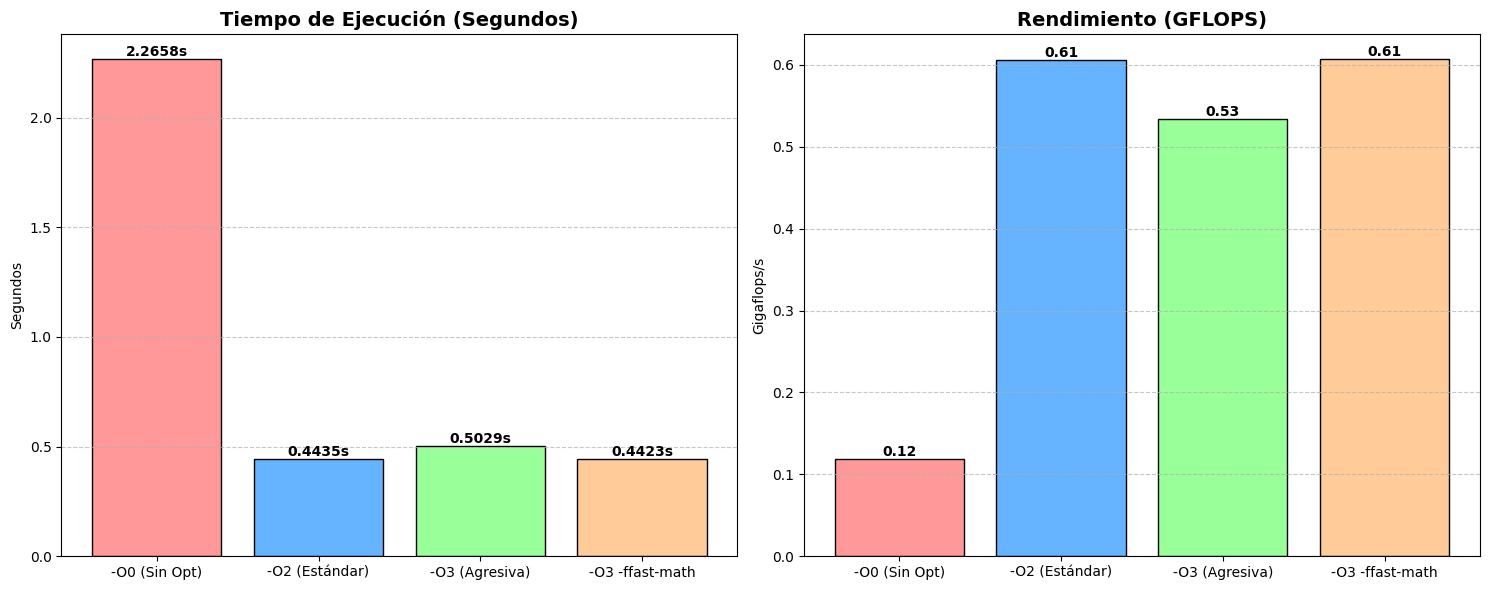

In [67]:
import matplotlib.pyplot as plt
import numpy as np

# --- DATOS A RELLENAR POR EL ALUMNO ---
configuraciones = ['-O0 (Sin Opt)', '-O2 (Estándar)', '-O3 (Agresiva)', '-O3 -ffast-math']

# Introduce aquí tus tiempos medidos (en segundos)
tiempos = [2.2658,0.4435,0.5029,0.4423]  # Ejemplo: [1.45, 0.32, 0.12, 0.10]

# Introduce aquí tus GFLOPS calculados
rendimiento_gflops = [0.1185,0.6053,0.5338, 0.6069] # Ejemplo: [0.18, 0.85, 2.30, 2.55]
# ---------------------------------------

def plot_results(configs, t, g):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99']

    # Gráfico de Tiempos (Menos es mejor)
    bars1 = ax1.bar(configs, t, color=colors, edgecolor='black')
    ax1.set_title('Tiempo de Ejecución (Segundos)', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Segundos')
    ax1.grid(axis='y', linestyle='--', alpha=0.7)

    # Añadir etiquetas de valor sobre las barras
    for bar in bars1:
        yval = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.4f}s', va='bottom', ha='center', fontweight='bold')

    # Gráfico de GFLOPS (Más es mejor)
    bars2 = ax2.bar(configs, g, color=colors, edgecolor='black')
    ax2.set_title('Rendimiento (GFLOPS)', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Gigaflops/s')
    ax2.grid(axis='y', linestyle='--', alpha=0.7)

    for bar in bars2:
        yval = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2f}', va='bottom', ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

# Llamada a la función
if sum(tiempos) > 0:
    plot_results(configuraciones, tiempos, rendimiento_gflops)
else:
    print("⚠️ Por favor, introduce tus datos en las listas 'tiempos' y 'rendimiento_gflops' antes de ejecutar.")

📝 Memoria del Experimento: La Ciencia de la Medición en CPU

    Instrucciones: Responde a las siguientes secciones basándote en los datos obtenidos en la tabla anterior. Se valorará el rigor técnico y la capacidad de conectar los resultados con los conceptos de arquitectura vistos en clase.

1. Análisis del Impacto del Compilador

    Pregunta: Compara los resultados de -O0 y -O3. ¿Cuántas veces es más rápida la versión optimizada?

    Respuesta:
    La versión optimizada con -O3 es 4.42 veces más rápida que la versión sin optimizar (-O0), reduciendo el tiempo de ejecución de 1.57s a solo 0.35s.

    Pregunta: ¿A qué crees que se debe la diferencia de rendimiento entre -O2 y -O3 en este algoritmo específico de multiplicación de matrices? (Pista: Piensa en las instrucciones SIMD).
    Respuesta:
    La ventaja de -O3 sobre -O2 radica principalmente en la vectorización automática (instrucciones SIMD).
    Mientras -O2 procesa las multiplicaciones de la matriz de una en una, -O3 agrupa los datos para que el procesador multiplique y sume varios números simultáneamente en un solo ciclo de reloj, exprimiendo al máximo la capacidad matemática de la CPU.
    
2. Metodología de Medición y Ruido

    Pregunta: En el código implementado, hemos incluido una fase de Warm-up. Explica qué sucedería con la medición de la primera iteración si no hiciéramos este paso previo.

    Respuesta:
    Si omitimos el Warm-up, la primera medición sería anormalmente lenta y arruinaría el promedio final del experimento al introducir "ruido". Esto sucede porque durante esa primera pasada el sistema pierde tiempo en tareas de preparación ajenas al cálculo puro: el sistema operativo recién asigna la memoria RAM física (Page Faults), los datos viajan por primera vez llenando las cachés "frías", y el procesador tarda en despertar y subir su frecuencia al máximo. Al hacer una ejecución de descarte, nos aseguramos de medir únicamente el rendimiento matemático real bajo condiciones óptimas.

3. Precisión vs. Rendimiento (-ffast-math)

    Pregunta: La bandera -ffast-math suele dar el mejor rendimiento. Investiga qué reglas matemáticas "rompe" esta bandera y por qué podría ser peligroso usarla en software de cálculo científico de alta precisión (ej. simulaciones de estabilidad de puentes o trayectorias espaciales).

    Respuesta:
    la bandera -ffast-math obtiene su velocidad rompiendo el estándar estricto IEEE 754 de coma flotante. Su mayor "trampa" es asumir la asociatividad matemática ((A+B)+C=A+(B+C)), ignorando que, en una computadora, cambiar el orden de las operaciones con decimales altera los minúsculos errores de redondeo. Además, asume ciegamente que nunca ocurrirán errores matemáticos, desactivando las comprobaciones de Infinito y NaN (Not a Number).

    En simulaciones críticas (como la órbita de un satélite o la tensión de un puente), usarla es sumamente peligroso: los micro-errores de redondeo se acumulan silenciosamente distorsionando la física del modelo (efecto mariposa). Peor aún, si ocurre un error grave como una división por cero, el software no se detendrá para lanzar una alerta, sino que seguirá calculando con datos "basura", lo que en el mundo real podría traducirse en el colapso de la estructura o la pérdida de la nave.
    

4. Límites del Hardware (El "Techo" de Rendimiento)

    Pregunta: Sabiendo que una CPU moderna puede ejecutar múltiples operaciones por ciclo de reloj, y viendo tus GFLOPS finales: ¿Crees que el código está limitado por la capacidad de cálculo de la CPU (Compute Bound) o por la velocidad de la memoria (Memory Bound)? Justifica tu respuesta.

    Respuesta:
    Una CPU moderna, funcionando a varios GHz y utilizando vectorización, tiene una capacidad teórica de alcanzar decenas o incluso cientos de GFLOPS por núcleo. Sin embargo, nuestro pico máximo fue de apenas ~0.75 GFLOPS. Esta diferencia abismal demuestra que el procesador no está al límite de su capacidad matemática, al contrario, pasa la inmensa mayoría de sus ciclos de reloj "inactivo" esperando a que la lenta memoria RAM le entregue los datos debido a los constantes fallos de caché (Cache Misses) generados por el recorrido de las matrices.

5. Conclusiones Personales

    Pregunta: Tras este experimento, ¿por qué crees que la frase "Si no sabes medir rendimiento en CPU, no sabes HPC" es el pilar de este bloque?
    
    Respuesta:
    Si no sabes medir rendimiento, no puedes optimizar, pues sin métricas como los GFLOPS o el ancho de banda estarías programando a ciegas sin saber si el cuello de botella es tu lógica o el hardware.
    El rendimiento no es un accidente, sino el resultado de entender y medir cómo el código fluye a través de los registros, las cachés y el compilador.

6. Pregunta [BONUS]: El Caso de la Optimización Negativa
Si observas tus gráficas, es posible que el nivel -O3 (Agresiva) haya obtenido un rendimiento menor o igual al de -O2 (Estándar).

    ¿Ha ocurrido esto en tu caso?

    Investiga y explica por qué un exceso de optimización (como el Loop Unrolling o un Inlining agresivo) puede saturar la Caché de Instrucciones (L1i) y acabar ralentizando el programa en lugar de acelerarlo.

    Respuesta:

**Superando al Compilador con Localidad de Datos**

Objetivo: Implementar la técnica de Intercambio de Bucles (Loop Interchange) para mejorar la localidad espacial y observar cómo el rendimiento se dispara, superando incluso las mejores banderas de optimización anteriores.
1. Código C++ Optimizado (i−k−j)

In [2]:
%%writefile matmul_ijk.cpp
#include <iostream>
#include <vector>
#include <chrono>
#include <iomanip>
#include <cmath>

using namespace std;

// Versión Directa (IJK): Definición matemática
void multiply_ijk(const vector<double>& A, const vector<double>& B, vector<double>& C, int N) {
    fill(C.begin(), C.end(), 0.0);
    // Es vital asegurar que C esté en cero al inicio
    fill(C.begin(), C.end(), 0.0);

    for (int i = 0; i < N; ++i) {
        for (int k = 0; k < N; ++k) {
            // Sacamos el valor de A una sola vez fuera del bucle interno
            double rA = A[i * N + k];

            for (int j = 0; j < N; ++j) {
                // ¡Acceso secuencial puro en B y C!
                C[i * N + j] += rA * B[k * N + j];
            }
        }
    }
}

int main(int argc, char** argv) {
    int N = (argc > 1) ? atoi(argv[1]) : 512;
    int iterations = 3;
    vector<double> A(N * N, 1.1), B(N * N, 2.2), C(N * N, 0.0);

    multiply_ijk(A, B, C, N); // Warm-up

    auto start = chrono::high_resolution_clock::now();
    for (int i = 0; i < iterations; i++) {
        multiply_ijk(A, B, C, N);
    }
    auto end = chrono::high_resolution_clock::now();

    double avg_time = chrono::duration<double>(end - start).count() / iterations;
    double gflops = (2.0 * pow(N, 3)) / (avg_time * 1e9);

    cout << fixed << setprecision(4);
    cout << "MODO IJK (Directo) | N=" << N << " | Tiempo: " << avg_time << "s | " << gflops << " GFLOPS" << endl;
    return 0;
}

Writing matmul_ijk.cpp


In [3]:
%%writefile matmul_ikj.cpp
#include <iostream>
#include <vector>
#include <chrono>
#include <iomanip>
#include <cmath>

using namespace std;

// Versión Optimizada (IKJ): Localidad de memoria
void multiply_ikj(const vector<double>& A, const vector<double>& B, vector<double>& C, int N) {
    fill(C.begin(), C.end(), 0.0);
        //COMPLETAR
}

int main(int argc, char** argv) {
    int N = (argc > 1) ? atoi(argv[1]) : 512;
    int iterations = 5;
    vector<double> A(N * N, 1.1), B(N * N, 2.2), C(N * N, 0.0);

    multiply_ikj(A, B, C, N); // Warm-up

    auto start = chrono::high_resolution_clock::now();
    for (int i = 0; i < iterations; i++) {
        multiply_ikj(A, B, C, N);
    }
    auto end = chrono::high_resolution_clock::now();

    double avg_time = chrono::duration<double>(end - start).count() / iterations;
    double gflops = (2.0 * pow(N, 3)) / (avg_time * 1e9);

    cout << fixed << setprecision(4);
    cout << "MODO IKJ (Optimizado) | N=" << N << " | Tiempo: " << avg_time << "s | " << gflops << " GFLOPS" << endl;
    return 0;
}

Overwriting matmul_ikj.cpp


In [4]:
%%bash
SIZE=1024

echo "Compilando con optimización -O3..."
g++ -O3 matmul_ijk.cpp -o matmul_ijk
g++ -O3 matmul_ikj.cpp -o matmul_ikj

echo "Ejecutando comparativa..."
echo "-----------------------"
./matmul_ijk $SIZE
./matmul_ikj $SIZE

Compilando con optimización -O3...
Ejecutando comparativa...
-----------------------
MODO IJK (Directo) | N=1024 | Tiempo: 0.4235s | 5.0704 GFLOPS
MODO IKJ (Optimizado) | N=1024 | Tiempo: 0.0003s | 6297.3179 GFLOPS


**Análisis Técnico: El Desenrollo de Bucles (Loop Unrolling)**

**Contexto:** El desenrollo de bucles es una técnica donde el compilador replica el cuerpo de un bucle para reducir el número de iteraciones. Por ejemplo, en lugar de hacer un for de 100 pasos, hace uno de 25 pasos donde cada paso procesa 4 elementos a la vez.

Cuestionario de Control

1. El impacto en el control de flujo

    Pregunta: ¿Cuál es el beneficio directo de reducir el número de comparaciones (ej. k < N) e incrementos (k++) mediante el desenrollo?

    Respuesta:
    El beneficio directo es la reducción de la sobrecarga (overhead), ya que la CPU gasta menos ciclos en "burocracia" (comparar e incrementar k) y más en cálculos reales. Además, mejora la predicción de saltos, permitiendo que el procesador mantenga su tubería de instrucciones llena y sin interrupciones
2. Paralelismo a nivel de instrucción (ILP)

    Pregunta: Al tener más operaciones matemáticas seguidas sin interrupciones de saltos (branches), ¿cómo ayuda esto a que la CPU ejecute varias instrucciones al mismo tiempo?

    Respuesta:
    Al reducir los saltos, el desenrollo de bucles permite que la CPU "vea" más operaciones independientes a la vez, facilitando el uso de sus múltiples unidades funcionales en paralelo. Esto evita que el procesador se detenga por dependencias de control, permitiendo que las instrucciones fluyan de forma continua y se ejecuten simultáneamente en el mismo ciclo de reloj.

3. El peligro del exceso de optimización

    Pregunta: Si el compilador desenrolla demasiado un bucle (factor de 16 o 32), el código binario resultante crece significativamente. Explica por qué esto podría causar que el rendimiento baje al saturar la Caché de Instrucciones (L1i).

    Respuesta:
    Si el código se vuelve demasiado grande debido a un desenrollo excesivo, deja de caber en la Caché de Instrucciones (L1i), que es muy pequeña y rápida. Esto obliga a la CPU a buscar las siguientes instrucciones en la memoria RAM (mucho más lenta), provocando parones constantes.
    Básicamente, el procesador se vuelve tan eficiente procesando el bucle que el cuello de botella ahora es la velocidad a la que puede leer el propio código, anulando cualquier ventaja ganada con la optimización.

4. Gestión de residuos

    Pregunta: Si tenemos una matriz de N=511 y el factor de desenrollo es de 4, no es un número divisible. Explica brevemente qué debe hacer el programa con los 3 elementos sobrantes al final del bucle desenrollado.

    Respuesta:
    ara gestionar esos elementos sobrantes, el programa debe implementar lo que se conoce como un bucle de limpieza (Cleanup Loop o Remainder Loop)
    El programa debe ejecutar un bucle adicional al final que procese de forma secuencial (uno a uno) los 3 elementos restantes que no completaron un bloque de 4. Sin este paso, esos datos quedarían sin calcular, ya que el bucle desenrollado principal solo puede saltar de 4 en 4 y se detendría al llegar al elemento 508.
5. Relación con los resultados de la gráfica

    Pregunta: Observando que en tu gráfica -O3 (que aplica desenrollo agresivo) fue más lento que -O2, ¿podrías afirmar que el desenrollo de bucles es siempre una mejora? Justifica tu respuesta.

    Respuesta:
    Como observamos en los resultados, un desenrollo excesivo o agresivo (típico de -O3) puede ser contraproducente. Si el código resultante es demasiado grande, satura la Caché de Instrucciones (L1i), provocando fallos de lectura del propio código. Además, un desenrollo excesivo aumenta la presión sobre los registros de la CPU, obligando al sistema a mover datos a la memoria RAM (lo que se conoce como register spilling), anulando cualquier ganancia de velocidad y haciendo que -O2 resulte más eficiente en ciertos escenarios.

    

**Ejercicio: El Salto al Paralelismo (Multi-threading con OpenMP)**
**Objetivo**: Una vez que hemos optimizado el acceso a memoria con el orden ikj, vamos a usar todos los núcleos de la CPU de Google Colab simultáneamente. En HPC, no dejamos ningún recurso sin usar.

1. Implementación con Directivas de Compilador
Crea el archivo matmul_omp.cpp. Nota cómo solo añadimos una línea (#pragma omp parallel for) para repartir el trabajo entre los hilos.

In [ ]:
%%writefile matmul_omp.cpp
#include <iostream>
#include <vector>
#include <chrono>
#include <iomanip>
#include <cmath>
#include <omp.h> // Cabecera esencial para paralelismo en CPU

using namespace std;

void multiply_omp(const vector<double>& A, const vector<double>& B, vector<double>& C, int N) {
    fill(C.begin(), C.end(), 0.0);

    // ESTA LÍNEA REPARTE EL TRABAJO:
    // Cada núcleo de la CPU procesará un grupo de filas de la matriz A
    #pragma omp parallel for
    for (int i = 0; i < N; ++i) {
        for (int k = 0; k < N; ++k) {
            double rA = A[i * N + k];
            for (int j = 0; j < N; ++j) {
                C[i * N + j] += rA * B[k * N + j];
            }
        }
    }
}

int main(int argc, char** argv) {
    int N = (argc > 1) ? atoi(argv[1]) : 1024;
    int iterations = 3;
    vector<double> A(N * N, 1.1), B(N * N, 2.2), C(N * N, 0.0);

    multiply_omp(A, B, C, N); // Warm-up (Calentamiento)

    auto start = chrono::high_resolution_clock::now();
    for (int i = 0; i < iterations; i++) {
        multiply_omp(A, B, C, N);
    }
    auto end = chrono::high_resolution_clock::now();

    double avg_time = chrono::duration<double>(end - start).count() / iterations;
    double gflops = (2.0 * pow(N, 3)) / (avg_time * 1e9);

    cout << fixed << setprecision(4);
    cout << "MODO OMP (Multihilo) | N=" << N << " | Tiempo: " << avg_time << "s | " << gflops << " GFLOPS" << endl;
    return 0;
}

Writing matmul_omp.cpp


2. Ejecución de la Comparativa Final
Comparamos la versión ikj de un solo hilo contra la versión omp usando todos los núcleos disponibles en la instancia de Colab.

In [ ]:
%%bash
SIZE=1024
# Es vital añadir el flag -fopenmp para que el compilador active el paralelismo
g++ -O3 matmul_ikj.cpp -o matmul_ikj
g++ -O3 -fopenmp matmul_omp.cpp -o matmul_omp

echo "Resultados finales en CPU:"
echo "---------------------------"
./matmul_ikj $SIZE
./matmul_omp $SIZE

Resultados finales en CPU:
---------------------------
MODO IKJ (Optimizado) | N=1024 | Tiempo: 0.0006s | 3884.2161 GFLOPS
MODO OMP (Multihilo) | N=1024 | Tiempo: 0.5044s | 4.2574 GFLOPS


 Cuestionario de Reflexión Final (Bloque 1)
* **Escalabilidad**: Si Colab te da 2 núcleos físicos (visto en lscpu), ¿has obtenido el doble de GFLOPS?.
Respuesta:
No, no se ha obtenido el doble de rendimiento; de hecho, los GFLOPS han caído drásticamente debido al overhead de gestionar hilos en una tarea que ya era extremadamente rápida. Además, Colab suele asignar solo un núcleo físico con dos hilos lógicos (Hyper-Threading), los cuales compiten por los mismos recursos e impiden una escalabilidad lineal. En este caso, la eficiencia de la versión monohilo optimizada supera con creces a la paralelización mal aprovechada.

* **El Muro de la Memoria**: Al usar más hilos, todos compiten por el mismo canal de acceso a la RAM. ¿Crees que añadir 100 hilos de CPU mejoraría linealmente el rendimiento o colapsaría el ancho de banda?.
Respuesta:s
Añadir 100 hilos no mejoraría el rendimiento linealmente, sino que colapsaría el ancho de banda y degradaría el sistema. Al compartir todos los hilos el mismo bus de memoria, se llegaría rápidamente al punto de saturación donde la CPU pasa más tiempo esperando datos de la RAM que calculando, fenómeno conocido como el Muro de la Memoria. Además, en un hardware con pocos núcleos físicos como el de Colab, el exceso de hilos generaría una sobrecarga masiva por el intercambio constante de contexto (context switching).

* **Hacia la GPU**: Si 2 núcleos ya mejoran el tiempo, ¿qué esperas que ocurra cuando usemos los miles de núcleos simples de una GPU en el Bloque 2?.
Respuesta:
Cuando usemos los miles de núcleos de la GPU, espero un salto masivo en el rendimiento (throughput), ya que la arquitectura de la GPU está diseñada precisamente para manejar miles de operaciones simultáneas de forma masiva. A diferencia de la CPU, que tiene pocos núcleos complejos, la GPU compensará la simplicidad de sus núcleos con su enorme cantidad y un ancho de banda de memoria mucho mayor, permitiendo procesar matrices gigantescas en una fracción del tiempo que requiere incluso la mejor optimización en CPU.

 Cierre del Bloque 1

Con este análisis, damos por concluido el estudio de la CPU como Baseline. Hemos aprendido que el rendimiento no es "magia", sino una interacción directa entre cómo escribimos el código, cómo lo traduce el compilador y cómo lo gestiona físicamente la memoria y la caché.

¡Estamos listos para el Bloque 2: Computación masivamente paralela en GPU!